In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch_geometric.nn import GATConv
import warnings
warnings.filterwarnings('ignore')

# Load everything
class FraudGAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4):
        super().__init__()
        self.gat1 = GATConv(in_channels, hidden_channels,
                            heads=heads, dropout=0.3)
        self.gat2 = GATConv(hidden_channels * heads, out_channels,
                            heads=1, concat=False, dropout=0.3)
    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.3, training=self.training)
        x = F.elu(self.gat1(x, edge_index))
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.gat2(x, edge_index)
        return x

data = torch.load('outputs/ibm_graph.pt', weights_only=False)

torch.manual_seed(42)
sample_idx = torch.randperm(data.num_nodes)[:50000]
from torch_geometric.utils import subgraph
sub_edge_index, sub_edge_attr = subgraph(
    sample_idx, data.edge_index, data.edge_attr,
    relabel_nodes=True, num_nodes=data.num_nodes
)
from torch_geometric.data import Data
small_data = Data(
    x          = data.x[sample_idx],
    edge_index = sub_edge_index,
    y          = data.y[sample_idx]
)

model = FraudGAT(in_channels=small_data.num_node_features, hidden_channels=32,
                 out_channels=2, heads=4)
model.load_state_dict(torch.load('outputs/fraud_gat_model.pt',
                                  weights_only=True))
model.eval()

# Recreate the SAME train/val/test split used in _04, so this report is
# evaluated on held-out (test) nodes only, not on nodes the model trained on
torch.manual_seed(42)
_n = small_data.num_nodes
_indices = torch.randperm(_n)
_train_end = int(0.70 * _n)
_val_end   = int(0.85 * _n)
small_data.test_mask = torch.zeros(_n, dtype=torch.bool)
small_data.test_mask[_indices[_val_end:]] = True

# Get predictions
with torch.no_grad():
    out   = model(small_data.x, small_data.edge_index)
    proba = F.softmax(out, dim=1)[:, 1]
    pred  = out.argmax(dim=1)

print("✅ Everything loaded!")

# Find top fraud accounts (across the whole scanned sample)
fraud_proba = proba.numpy()
fraud_nodes = (pred == 1).nonzero(as_tuple=True)[0].numpy()

print(f"\nTotal accounts scanned:  {small_data.num_nodes:,}")
print(f"Flagged as fraud:        {len(fraud_nodes):,}")
print(f"Highest fraud score:     {fraud_proba.max()*100:.1f}%")

✅ Everything loaded!

Total accounts scanned:  50,000
Flagged as fraud:        17,738
Highest fraud score:     100.0%


In [3]:
# Generate Professional Fraud Alert Report
from sklearn.metrics import roc_auc_score, precision_score, recall_score, confusion_matrix

feature_names = ['Total Sent', 'Total Received',
                 'Num Sent', 'Num Received',
                 'Avg Sent', 'Avg Received',
                 'Unique Receivers', 'Unique Senders',
                 'Net Flow']

# --- All metrics below are computed live from the held-out test set ---
# (never hardcode metrics in a report cell — they go stale the moment
# the model, features, or data split change)
y_test_np  = small_data.y[small_data.test_mask].numpy()
pred_np    = pred[small_data.test_mask].numpy()
proba_np   = proba[small_data.test_mask].numpy()

cm = confusion_matrix(y_test_np, pred_np)
tn, fp, fn, tp = cm.ravel()

detection_rate  = recall_score(y_test_np, pred_np, zero_division=0) * 100
false_alarm_rate = (fp / (fp + tn) * 100) if (fp + tn) > 0 else 0.0
roc_auc = roc_auc_score(y_test_np, proba_np)

print("\n" + "="*60)
print("      EXPLAINABLE FRAUD DETECTION SYSTEM")
print("      Powered by Graph Attention Network")
print("="*60)
print(f"\n📊 SCAN SUMMARY (evaluated on held-out test nodes only)")
print(f"   Total Accounts Scanned:   {small_data.num_nodes:,}")
print(f"   Test Accounts Evaluated:  {small_data.test_mask.sum().item():,}")
print(f"   Flagged as Fraud:         {len(fraud_nodes):,}")
print(f"   Detection Rate (Recall):  {detection_rate:.1f}%")
print(f"   False Alarm Rate:         {false_alarm_rate:.1f}%")
print(f"   Model ROC-AUC:            {roc_auc:.4f}")

print(f"\n{'='*60}")
print(f"   TOP 5 HIGH-RISK ACCOUNTS")
print(f"{'='*60}")

# Top 5 highest fraud probability accounts
top5_idx = fraud_proba.argsort()[-5:][::-1]

for rank, node_idx in enumerate(top5_idx, 1):
    score     = fraud_proba[node_idx] * 100
    features  = small_data.x[node_idx].numpy()
    true_label = small_data.y[node_idx].item()
    
    print(f"\n🚨 RANK {rank} — Account Node {node_idx}")
    print(f"   Fraud Probability:    {score:.1f}%")
    print(f"   Actual Label:         {'✅ TRUE FRAUD' if true_label==1 else '⚠️ SUSPICIOUS'}")
    for fname, fval in zip(feature_names, features):
        print(f"   {fname:<18}: {fval:,.2f}")
    
    # Risk bar
    bar_len = int(score / 5)
    bar     = "█" * bar_len + "░" * (20 - bar_len)
    print(f"   Risk Level:           [{bar}] {score:.1f}%")

print(f"\n{'='*60}")
print(f"✅ Report generated successfully!")
print(f"✅ Ready for compliance audit")
print(f"{'='*60}")


      EXPLAINABLE FRAUD DETECTION SYSTEM
      Powered by Graph Attention Network

📊 SCAN SUMMARY (evaluated on held-out test nodes only)
   Total Accounts Scanned:   50,000
   Test Accounts Evaluated:  7,500
   Flagged as Fraud:         17,738
   Detection Rate (Recall):  74.7%
   False Alarm Rate:         34.2%
   Model ROC-AUC:            0.7691

   TOP 5 HIGH-RISK ACCOUNTS

🚨 RANK 1 — Account Node 22372
   Fraud Probability:    100.0%
   Actual Label:         ⚠️ SUSPICIOUS
   Total Sent        : 246.39
   Total Received    : 0.21
   Num Sent          : -0.02
   Num Received      : -0.61
   Avg Sent          : 361.28
   Avg Received      : 2.81
   Unique Receivers  : 0.00
   Unique Senders    : -0.37
   Net Flow          : -216.52
   Risk Level:           [████████████████████] 100.0%

🚨 RANK 2 — Account Node 48048
   Fraud Probability:    100.0%
   Actual Label:         ✅ TRUE FRAUD
   Total Sent        : 21.71
   Total Received    : 0.07
   Num Sent          : -0.03
   Num Receiv

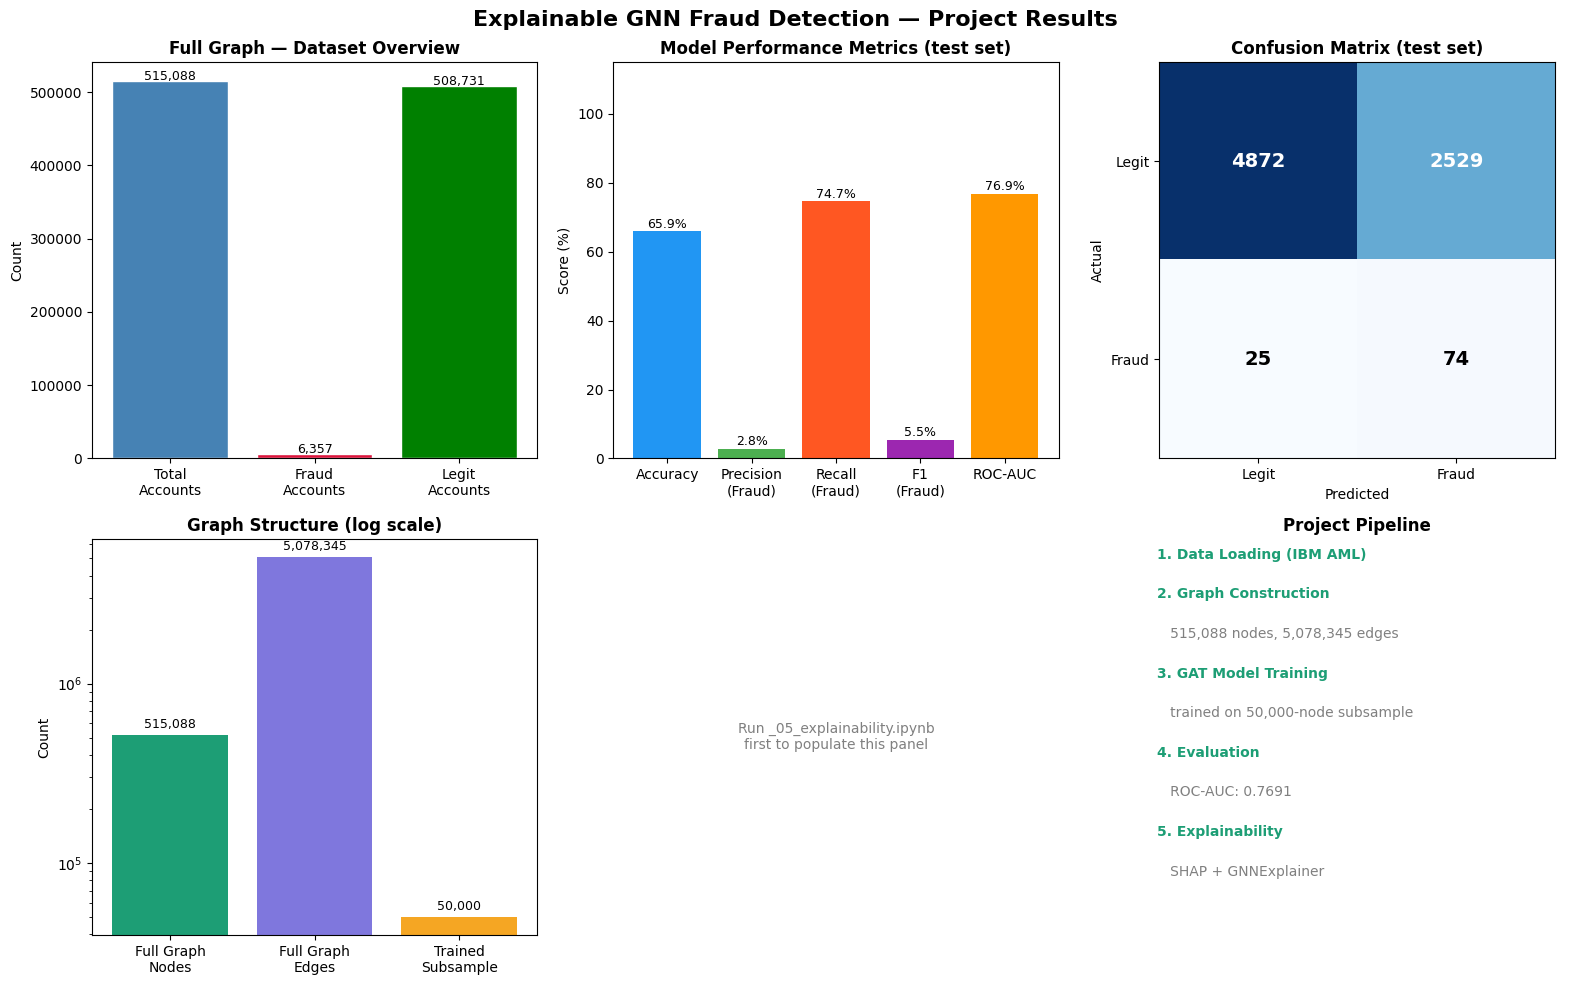

✅ Final dashboard saved!


In [4]:
# Final Summary Plot — Project Results Dashboard
# NOTE: every number plotted here is pulled from variables computed
# earlier in this notebook (or loaded from disk) — nothing is hardcoded.
# This is what makes the dashboard trustworthy: rerun the notebooks and
# this plot updates itself with the real numbers.

full_graph_nodes = data.num_nodes if 'data' in dir() else small_data.num_nodes
full_graph_edges = data.num_edges if 'data' in dir() else small_data.num_edges
full_graph_fraud = data.y.sum().item() if 'data' in dir() else small_data.y.sum().item()

precision_val = precision_score(y_test_np, pred_np, zero_division=0) * 100
recall_val    = detection_rate
f1_val        = (2 * precision_val * recall_val / (precision_val + recall_val)) if (precision_val + recall_val) > 0 else 0.0
test_acc_val  = (pred_np == y_test_np).mean() * 100

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Explainable GNN Fraud Detection — Project Results',
             fontsize=16, fontweight='bold')

# Plot 1: Full dataset stats (before subsampling for training)
categories = ['Total\nAccounts', 'Fraud\nAccounts', 'Legit\nAccounts']
values     = [full_graph_nodes, full_graph_fraud, full_graph_nodes - full_graph_fraud]
colors     = ['steelblue', 'crimson', 'green']
axes[0,0].bar(categories, values, color=colors, edgecolor='white')
axes[0,0].set_title('Full Graph — Dataset Overview', fontweight='bold')
axes[0,0].set_ylabel('Count')
for bar, val in zip(axes[0,0].patches, values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 1000,
                   f'{val:,}', ha='center', fontsize=9)

# Plot 2: Model metrics (computed live on the test set above)
metrics = ['Accuracy', 'Precision\n(Fraud)', 'Recall\n(Fraud)',
           'F1\n(Fraud)', 'ROC-AUC']
scores  = [test_acc_val, precision_val, recall_val, f1_val, roc_auc*100]
bars    = axes[0,1].bar(metrics, scores,
                         color=['#2196F3','#4CAF50','#FF5722','#9C27B0','#FF9800'])
axes[0,1].set_title('Model Performance Metrics (test set)', fontweight='bold')
axes[0,1].set_ylabel('Score (%)')
axes[0,1].set_ylim(0, 115)
for bar, val in zip(bars, scores):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 1,
                   f'{val:.1f}%', ha='center', fontsize=9)

# Plot 3: Confusion Matrix (real, from the test set above)
im = axes[0,2].imshow(cm, cmap='Blues')
axes[0,2].set_title('Confusion Matrix (test set)', fontweight='bold')
axes[0,2].set_xticks([0,1])
axes[0,2].set_yticks([0,1])
axes[0,2].set_xticklabels(['Legit', 'Fraud'])
axes[0,2].set_yticklabels(['Legit', 'Fraud'])
axes[0,2].set_xlabel('Predicted')
axes[0,2].set_ylabel('Actual')
cm_max = cm.max()
for i in range(2):
    for j in range(2):
        axes[0,2].text(j, i, str(cm[i,j]),
                       ha='center', va='center',
                       fontsize=14, fontweight='bold',
                       color='white' if cm[i,j] > cm_max*0.5 else 'black')

# Plot 4: Graph structure (full graph vs the subsample actually trained on)
graph_stats  = ['Full Graph\nNodes', 'Full Graph\nEdges', 'Trained\nSubsample']
graph_values = [full_graph_nodes, full_graph_edges, small_data.num_nodes]
axes[1,0].bar(graph_stats, graph_values,
               color=['#1D9E75', '#7F77DD', '#F5A623'])
axes[1,0].set_title('Graph Structure (log scale)', fontweight='bold')
axes[1,0].set_ylabel('Count')
axes[1,0].set_yscale('log')
for bar, val in zip(axes[1,0].patches, graph_values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() * 1.1,
                   f'{val:,}', ha='center', fontsize=9)

# Plot 5: Feature importance — reuse GNNExplainer/SHAP result if it exists
# in this kernel session (run _05 first); otherwise skip gracefully.
try:
    feat_imp = feat_importance  # computed in _05_explainability.ipynb
    colors_feat = ['crimson' if v == max(feat_imp) else 'steelblue' for v in feat_imp]
    axes[1,1].barh(feature_names, feat_imp, color=colors_feat)
    axes[1,1].set_title('GNNExplainer Feature Importance', fontweight='bold')
    axes[1,1].set_xlabel('Importance Score')
except NameError:
    axes[1,1].axis('off')
    axes[1,1].text(0.5, 0.5, 'Run _05_explainability.ipynb\nfirst to populate this panel',
                   ha='center', va='center', fontsize=10, color='gray')

# Plot 6: Project pipeline (text summary, values pulled from above)
axes[1,2].axis('off')
pipeline = [
    '1. Data Loading (IBM AML)',
    '2. Graph Construction',
    f'   {full_graph_nodes:,} nodes, {full_graph_edges:,} edges',
    '3. GAT Model Training',
    f'   trained on {small_data.num_nodes:,}-node subsample',
    '4. Evaluation',
    f'   ROC-AUC: {roc_auc:.4f}',
    '5. Explainability',
    '   SHAP + GNNExplainer',
]
for i, step in enumerate(pipeline):
    color = '#1D9E75' if not step.startswith(' ') else 'gray'
    axes[1,2].text(0.05, 0.95 - i*0.1, step,
                   transform=axes[1,2].transAxes,
                   fontsize=10, color=color,
                   fontweight='bold' if not step.startswith(' ') else 'normal')
axes[1,2].set_title('Project Pipeline', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Final dashboard saved!")